In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Train LDA        

In [13]:
lda = LinearDiscriminantAnalysis(solver="lsqr")
lda.fit(X_train, y_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'lsqr'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


## Predict & Evaluate   

In [14]:
y_pred = lda.predict(X_test)

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred))

Accuracy :  1.0
Confusion Matrix: 
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


## Dimensionality Reduction with LDA 

LDA is also a feature extractor     

In [15]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

## Visualize    

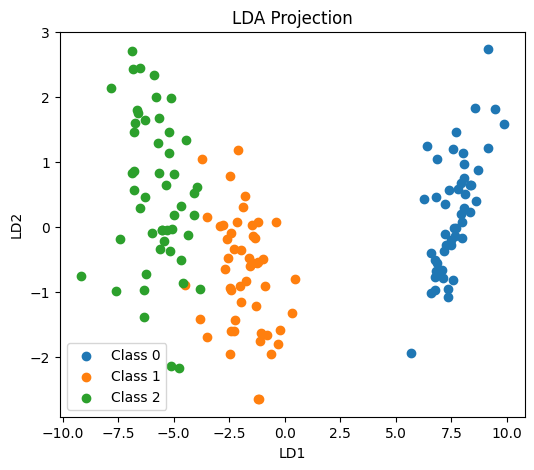

In [16]:
plt.figure(figsize=(6,5))

for label in np.unique(y): 
    plt.scatter(
        X_lda[y == label, 0], 
        X_lda[y == label, 1], 
        label = f"Class {label}"
    )



plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.title("LDA Projection")
plt.show()





## Inspecting the Model     

In [22]:
lda.means_ # class means mu_k
lda.coef_ # linear weights 
lda.intercept_ # intercept terms

array([-15.47783673,  -2.02197415, -33.53768674])

In [23]:
lda.decision_function(X_test[:5])

array([[-47.53998339,   2.12951847,  -5.62703269],
       [ 31.60575349, -18.4773681 , -64.165883  ],
       [-99.99342758,  14.25411606,  34.7018139 ],
       [-49.79925897,   1.82467659,  -3.06291524],
       [-48.96830586,   2.13976264,  -4.20895441]])